###**SHETH L.U.J. & SIR M.V. COLLEGE**

Vedant Patil | T101

Aim : Logistic Regression and Decision Tree
* Build a logistic regression model to predict a binary outcome.
* Evaluate the model's performance using classification metrics (e.g., accuracy, precision, recall).
* Construct a decision tree model and interpret the decision rules for classification.




1. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt


2. Load the Dataset

In [ ]:
df = pd.read_csv('pokemon.csv')
df.head()


,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,5,80,65,80,fire,NaN,19.0,1,0


3. Encode Categorical Variables

In [ ]:
df['type2'] = df['type2'].fillna('None')
df_encoded = pd.get_dummies(df, columns=['type1', 'type2'], drop_first=True)


4. Define Features and Target

In [ ]:
# Columns to exclude from features (X) because they are either the target, identifiers, or non-numeric strings
exclude_cols = ['is_legendary', 'pokedex_number', 'name', 'japanese_name', 'classfication', 'abilities', 'capture_rate']

# Identify all object-type columns that are not the target variable
object_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()

# Combine explicitly excluded columns with dynamically identified object columns
# Ensure 'is_legendary' is not accidentally dropped if it's an object type for some reason.
all_cols_to_drop = list(set(exclude_cols + object_cols) - set(['is_legendary']))

X = df_encoded.drop(columns=all_cols_to_drop, errors='ignore') # Use errors='ignore' in case a column was already dropped or doesn't exist
y = df_encoded['is_legendary']

# Explicitly convert all columns in X to numeric, coercing errors to NaN
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Fill any NaNs created by coercion or originally present in numeric columns
X = X.fillna(0) # Filling NaNs with 0 as a default strategy

5. Split Data Into Train and Test Sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


6. Feature Scaling

In [ ]:
scaler = StandardScaler()
# X_train and X_test should now contain only numerical features for scaling,
# as non-numeric columns were handled in the feature definition step (cell Y_lKg6y02v9x).
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

LOGISTIC REGRESSION SECTION

7. Train Logistic Regression Model

In [ ]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000)

8. Predict and Evaluate Logistic Regression

In [ ]:
y_pred_lr = logreg.predict(X_test_scaled)
print("Logistic Regression Metrics:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))


Logistic Regression Metrics:
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       147
           1       1.00      1.00      1.00        14

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161

Confusion Matrix:
 [[147   0]
 [  0  14]]


9. Confusion Matrix (Heatmap Plot)

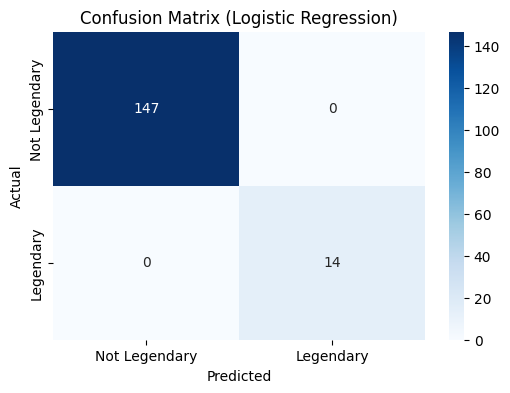

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Legendary','Legendary'], yticklabels=['Not Legendary','Legendary'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Logistic Regression)')
plt.show()


10. ROC Curve and AUC

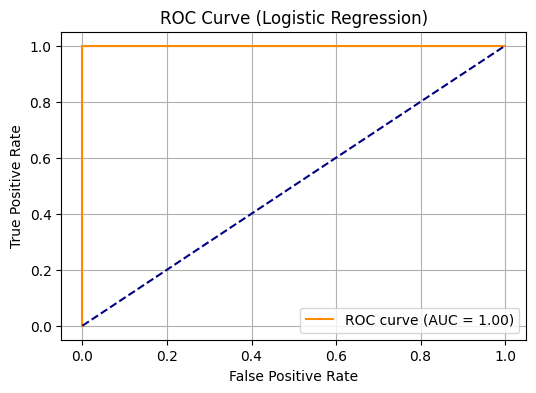

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr)
roc_auc = roc_auc_score(y_test, y_proba_lr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Logistic Regression)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


11. Bar Plot of Evaluation Metrics

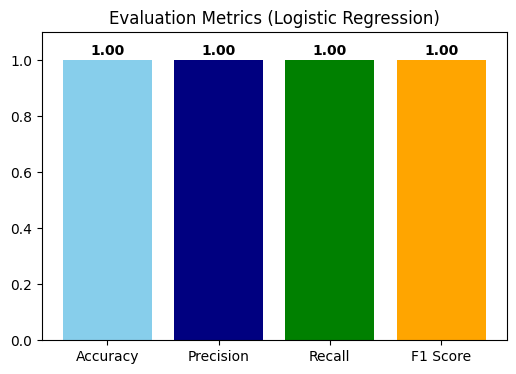

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1 Score': f1_score(y_test, y_pred_lr)
}

plt.figure(figsize=(6,4))
plt.bar(metrics.keys(), metrics.values(), color=['skyblue', 'navy', 'green', 'orange'])
plt.ylim(0, 1.1)
plt.title('Evaluation Metrics (Logistic Regression)')
for i, v in enumerate(metrics.values()):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()


DECISION TREE SECTION

12. Train Decision Tree Model

In [ ]:
clf = DecisionTreeClassifier(random_state=0)
clf.fit(X_train, y_train)


DecisionTreeClassifier(random_state=0)

13. Predict and Evaluate Decision Tree

In [ ]:
y_pred_dt = clf.predict(X_test)
print("\nDecision Tree Metrics:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_dt), 4))
print(classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))



Decision Tree Metrics:
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       147
           1       1.00      1.00      1.00        14

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161

Confusion Matrix:
 [[147   0]
 [  0  14]]


14. Confusion Matrix (Heatmap)

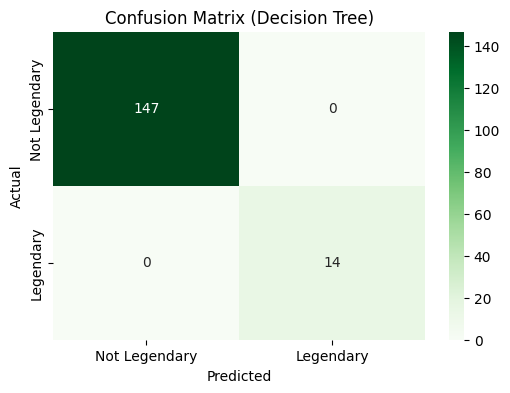

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', xticklabels=['Not Legendary','Legendary'], yticklabels=['Not Legendary','Legendary'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Decision Tree)')
plt.show()


15. ROC Curve and AUC

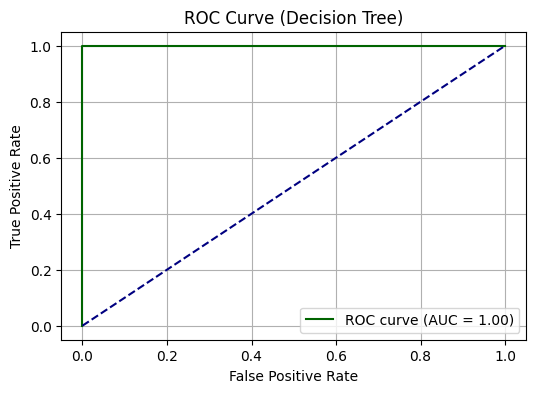

In [ ]:
y_proba_dt = clf.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_proba_dt)
roc_auc_dt = roc_auc_score(y_test, y_proba_dt)

plt.figure(figsize=(6,4))
plt.plot(fpr_dt, tpr_dt, color='darkgreen', label=f'ROC curve (AUC = {roc_auc_dt:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Decision Tree)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


16. Pruning the Decision Tree & Plotting Accuracy vs Alpha

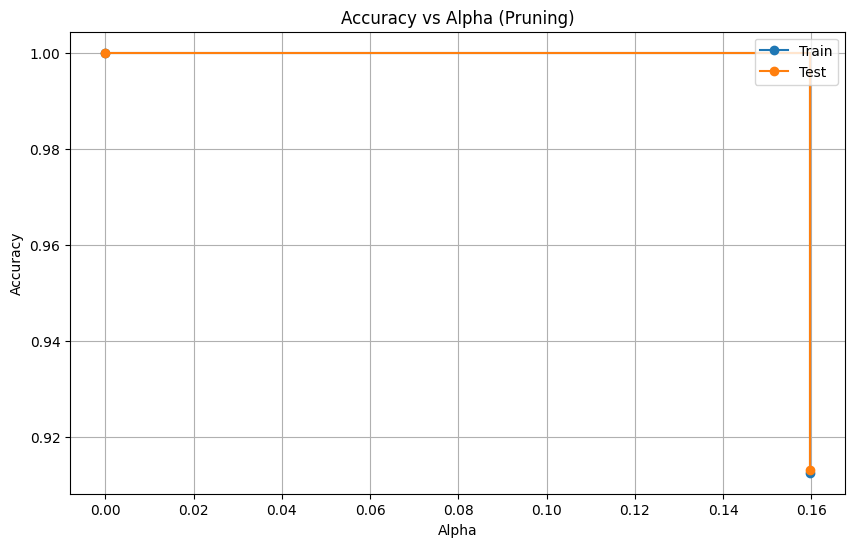

In [ ]:
# Compute the pruning path
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Train trees for each alpha
clfs = []
for alpha in ccp_alphas:
    clf_alpha = DecisionTreeClassifier(random_state=0, ccp_alpha=alpha)
    clf_alpha.fit(X_train, y_train)
    clfs.append(clf_alpha)

train_scores = [c.score(X_train, y_train) for c in clfs]
test_scores = [c.score(X_test, y_test) for c in clfs]

# Plotting accuracy vs alpha
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, train_scores, marker='o', label='Train', drawstyle="steps-post")
plt.plot(ccp_alphas, test_scores, marker='o', label='Test', drawstyle="steps-post")
plt.xlabel('Alpha')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Alpha (Pruning)')
plt.legend()
plt.grid(True)
plt.show()


17. Fit and Evaluate A Pruned Decision Tree

In [ ]:
chosen_alpha = 0.01  # Change based on your plot
clf_pruned = DecisionTreeClassifier(random_state=0, ccp_alpha=chosen_alpha)
clf_pruned.fit(X_train, y_train)

y_pred_pruned = clf_pruned.predict(X_test)
print("Pruned Decision Tree Test Accuracy:", accuracy_score(y_test, y_pred_pruned))
print(classification_report(y_test, y_pred_pruned))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_pruned))


Pruned Decision Tree Test Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       147
           1       1.00      1.00      1.00        14

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161

Confusion Matrix:
 [[147   0]
 [  0  14]]


18. Visualize The Pruned Tree

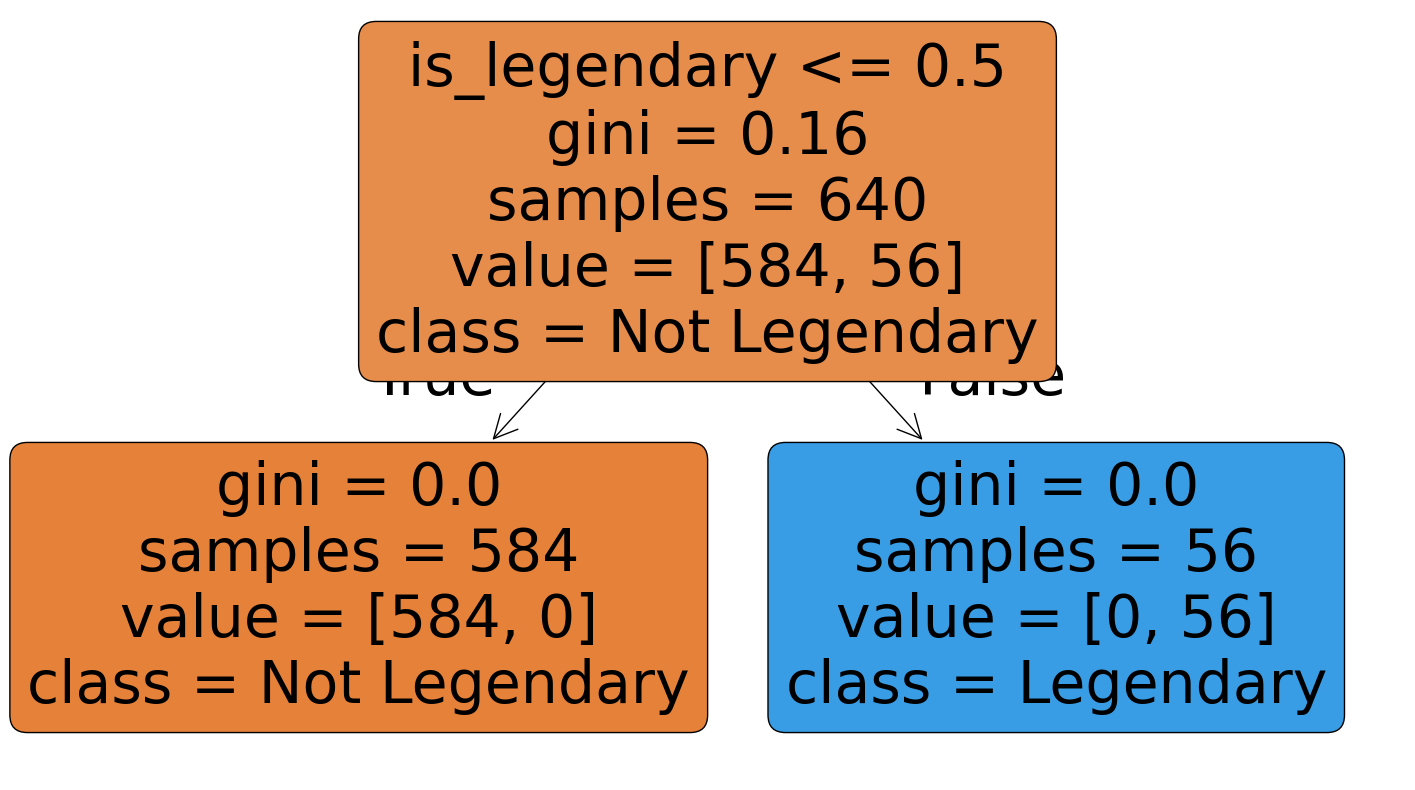

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(
    clf_pruned,
    feature_names=X.columns,
    class_names=['Not Legendary', 'Legendary'],
    filled=True,
    rounded=True
)
plt.show()
